In [1]:
import pandas as pd
import numpy as np

In [12]:
df = pd.read_excel("Radiomic feature Normal,EMCI,MCI,LMCI,AD WM.xlsx" ,header = None)
print(df.shape)
print(df.columns)
df.head()
print(df.shape)
print(df.iloc[:5, :5])

(2500, 56)
Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
       54, 55],
      dtype='int64')
(2500, 56)
          0         1         2         3         4
0  0.779461  0.630464  0.413104  0.367678  0.421142
1  0.893845  0.718463  0.502141  0.273205  0.171461
2  0.680705  0.673802  0.367183  0.218595  0.368003
3  0.685270  0.653717  0.369922  0.259070  0.426952
4  0.618119  0.617172  0.152592  0.582304  0.334561


In [14]:
labels = (
    ['Normal'] * 500 +
    ['EMCI'] * 500 +
    ['MCI'] * 500 +
    ['LMCI'] * 500 +
    ['AD'] * 500
)

df['label'] = labels

print(df['label'].value_counts())

label
Normal    500
EMCI      500
MCI       500
LMCI      500
AD        500
Name: count, dtype: int64


In [16]:
X = df.drop('label', axis=1)
y = df['label']

print(X.shape)
print(y.shape)

(2500, 56)
(2500,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
from sklearn.metrics import accuracy_score, classification_report

pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

Accuracy: 0.974
              precision    recall  f1-score   support

          AD       0.95      0.93      0.94       100
        EMCI       1.00      1.00      1.00       100
        LMCI       1.00      1.00      1.00       100
         MCI       0.93      0.94      0.94       100
      Normal       0.99      1.00      1.00       100

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500



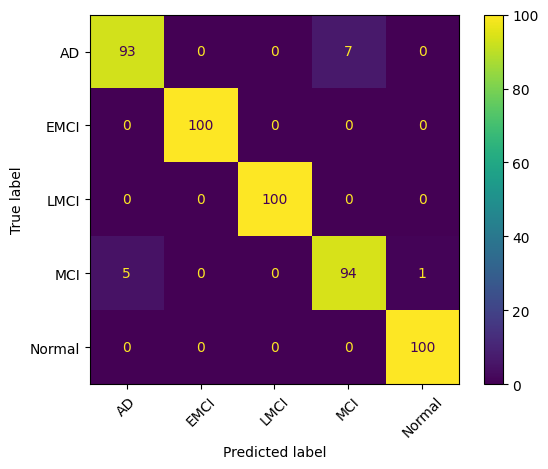

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    xticks_rotation=45
)

plt.show()

In [22]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Std:", scores.std())

Scores: [0.966 0.936 0.918 0.944 0.946]
Mean Accuracy: 0.942
Std: 0.015543487382180329


In [23]:
import pandas as pd

rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(20))

   Feature  Importance
6        6    0.084560
0        0    0.057887
7        7    0.055485
42      42    0.046694
5        5    0.043992
51      51    0.038822
43      43    0.033811
32      32    0.030307
8        8    0.025158
1        1    0.023877
4        4    0.023602
27      27    0.022863
55      55    0.022826
38      38    0.022052
14      14    0.021519
45      45    0.020293
25      25    0.017474
37      37    0.017014
29      29    0.016655
11      11    0.015567


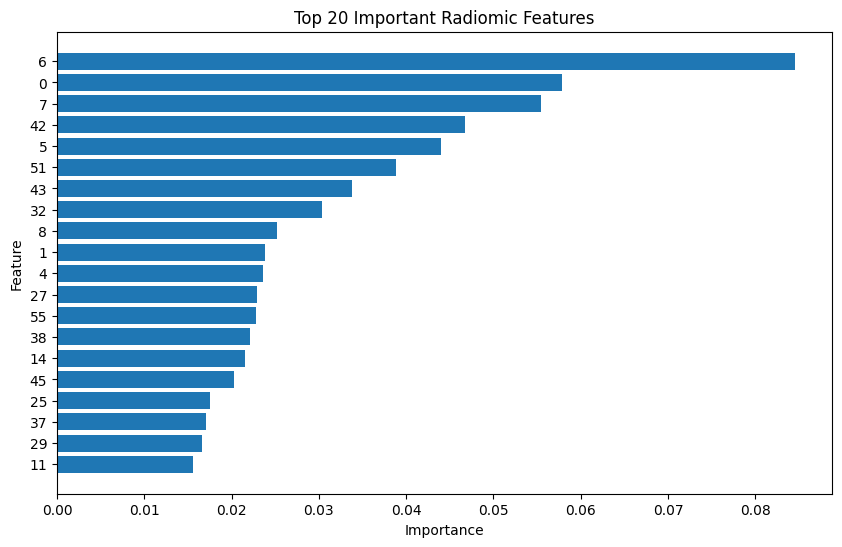

In [24]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(10,6))
plt.barh(top20['Feature'].astype(str),
         top20['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Important Radiomic Features')
plt.gca().invert_yaxis()
plt.show()

In [25]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

scores = cross_val_score(
    xgb,
    X,
    y_enc,
    cv=5,
    scoring='accuracy'
)

print(scores)
print(scores.mean())

[0.974 0.968 0.966 0.952 0.952]
0.9623999999999999


Accuracy: 0.98

Classification Report:
              precision    recall  f1-score   support

          AD       0.96      0.96      0.96       100
        EMCI       1.00      0.99      0.99       100
        LMCI       1.00      1.00      1.00       100
         MCI       0.95      0.95      0.95       100
      Normal       0.99      1.00      1.00       100

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



<Figure size 800x600 with 0 Axes>

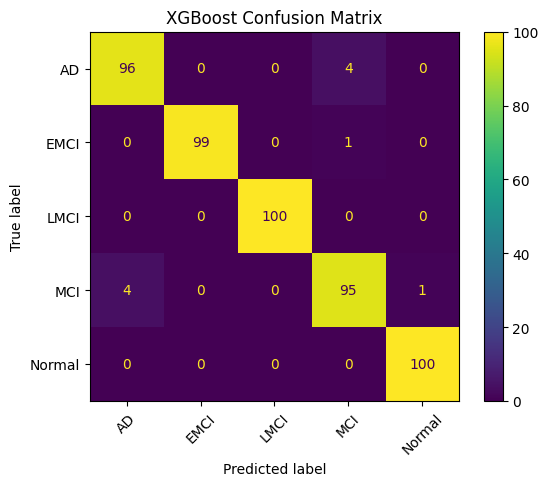

In [27]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score
import matplotlib.pyplot as plt

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=42
)

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

# Predictions
y_pred = xgb.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

# Confusion Matrix
plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=le.classes_,
    cmap='viridis',
    xticks_rotation=45
)
plt.title("XGBoost Confusion Matrix")
plt.show()

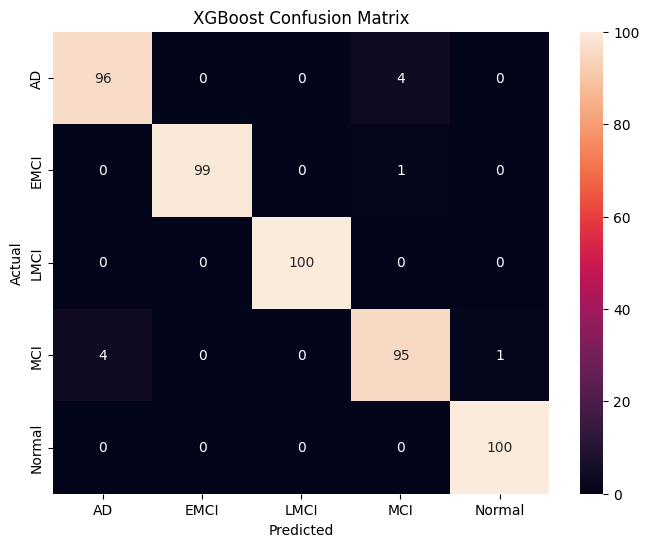

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()